In [2]:
%cd /content/drive/MyDrive/DeepLearning/FinalProject

/content/drive/MyDrive/DeepLearning/FinalProject


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Saved plot to figures/Transformer_CQT_notewise_f1.png


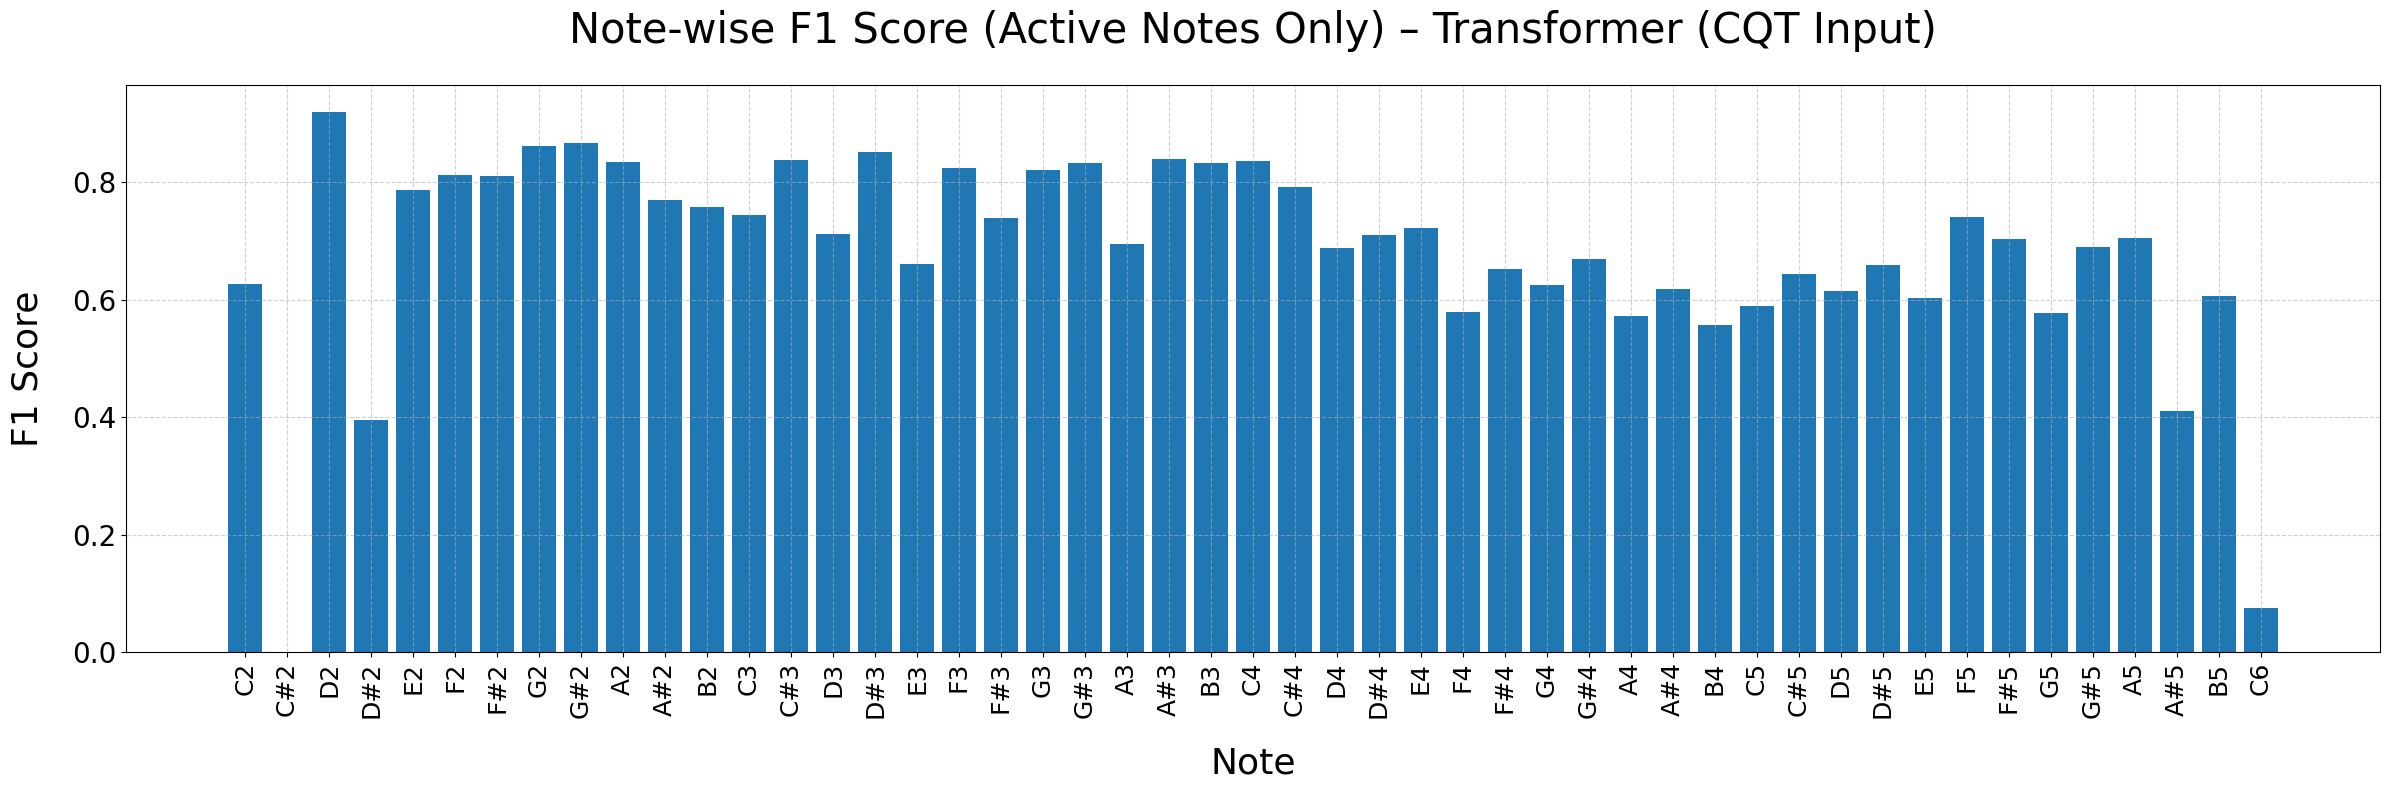

In [3]:
import os
import torch
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from utils.dataset import load_split_data, slice_into_windows, WindowedNoteDataset
from models.gru import GRUNoteClassifier
from models.transformer import TinyTransformer
from models.cnn import CNNMelNoteClassifier

# ==== SETTINGS ====
model_key = "Transformer_CQT"
checkpoint_path = "checkpoints/Final/Transformer_CQT_280425_183201/best.pth"
threshold = 0.25
save_path = f"figures/{model_key}_notewise_f1.png"

# ==== Ensure output directory exists ====
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# ==== Helper functions ====
def midi_to_note_name(midi_num):
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    octave = (midi_num // 12) - 1
    note = note_names[midi_num % 12]
    return f"{note}{octave}"

def get_model(model_key, params):
    key = model_key.lower()
    if key == "gru":
        return GRUNoteClassifier(
            input_dim=params["input_dim"],
            hidden_dim=params["model_dim"],
            num_layers=params["num_layers"],
            dropout=params["dropout"]
        )
    elif key == "transformer":
        return TinyTransformer(
            input_dim=params["input_dim"],
            model_dim=params["model_dim"],
            num_heads=params["num_heads"],
            num_layers=params["num_layers"],
            output_dim=88,
            dropout=params["dropout"]
        )
    elif key == "cnn":
        return CNNMelNoteClassifier()
    else:
        raise ValueError(f"Unknown model key: {model_key}")

def get_test_ids(csv_path="data_processing/bach_piece_splits.csv"):
    df = pd.read_csv(csv_path)
    return df[df["split"] == "test"]["id"].astype(str).tolist()

def compute_and_plot_notewise_f1(model, loader, threshold, save_path=None):
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(model.device)
            Y_batch = Y_batch.to(model.device)

            if isinstance(model, CNNMelNoteClassifier) and X_batch.ndim == 3:
                X_batch = X_batch.unsqueeze(1)
                Y_batch = (Y_batch.sum(dim=1) > 0).float()

            logits = model(X_batch)
            all_logits.append(logits.cpu())
            all_labels.append(Y_batch.cpu())

    all_logits = torch.cat(all_logits).reshape(-1, 88)
    all_labels = torch.cat(all_labels).reshape(-1, 88).numpy()
    preds = (torch.sigmoid(all_logits) > threshold).float().numpy()

    f1s_all = f1_score(all_labels, preds, average=None, zero_division=0)
    active_mask = (all_labels.sum(axis=0) + preds.sum(axis=0)) > 0
    f1s = f1s_all[active_mask]

    midi_range = np.arange(21, 109)[active_mask]
    note_labels = [midi_to_note_name(m) for m in midi_range]

    plt.figure(figsize=(24, 8))
    plt.bar(note_labels, f1s)
    plt.xlabel("Note", fontsize=26, labelpad=20)
    plt.ylabel("F1 Score", fontsize=26, labelpad=20)
    plt.title("Note-wise F1 Score (Active Notes Only) – Transformer (CQT Input)", fontsize=30, pad=30)
    plt.xticks(rotation=90, fontsize=18)
    plt.yticks(fontsize=20)
    plt.grid(True, which='major', linestyle='--', alpha=0.6)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight')
        print(f"Saved plot to {save_path}")

    plt.show()

# ==== Load config & model ====
with open("hparams.yaml") as f:
    hparams = yaml.safe_load(f)[model_key]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(hparams["model_name"], hparams)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.device = device

# ==== Load test data ====
test_ids = get_test_ids()
X_test, Y_test = load_split_data(hparams["input_type"], test_ids, split="test")
X_windows, Y_windows = slice_into_windows(X_test, Y_test, window_size=512, stride=256)
test_dataset = WindowedNoteDataset(X_windows, Y_windows)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==== Run and plot ====
compute_and_plot_notewise_f1(model, test_loader, threshold=threshold, save_path=save_path)


In [ ]:
import json
import matplotlib.pyplot as plt

# CQT

## GRU

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 128
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.5828
Best Val Epoch: 500


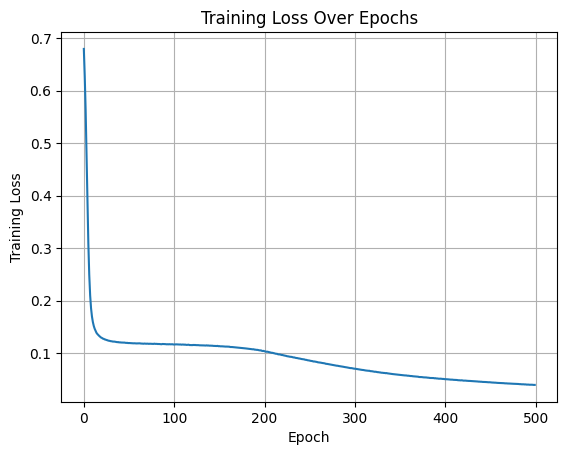

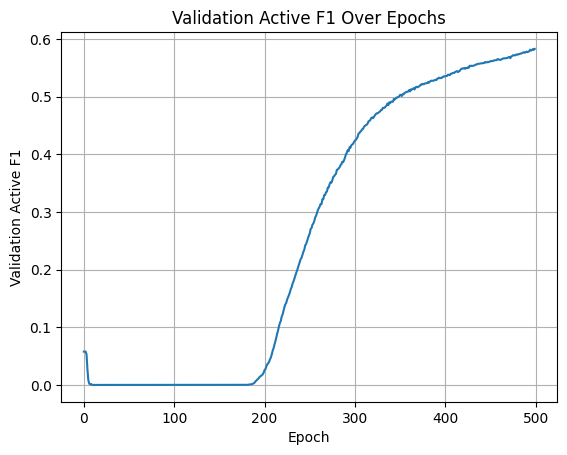

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_0_200425_152217.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 128
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6246
Best Val Epoch: 289


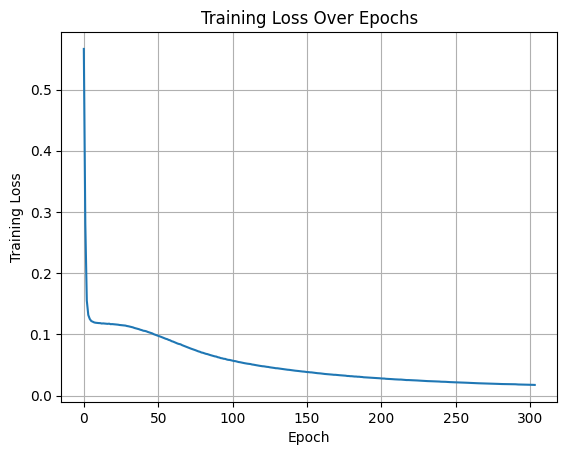

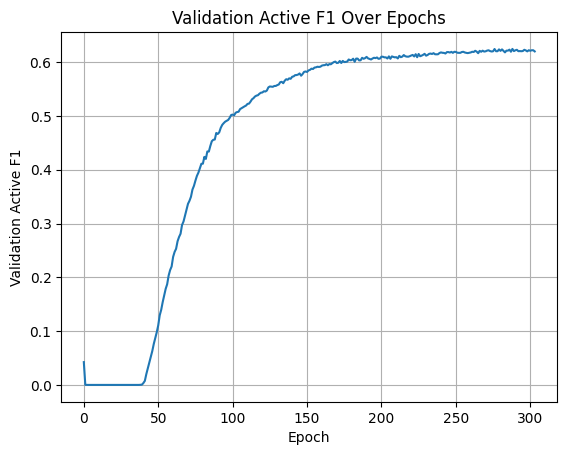

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_1_200425_155639.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 128
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.5846
Best Val Epoch: 500


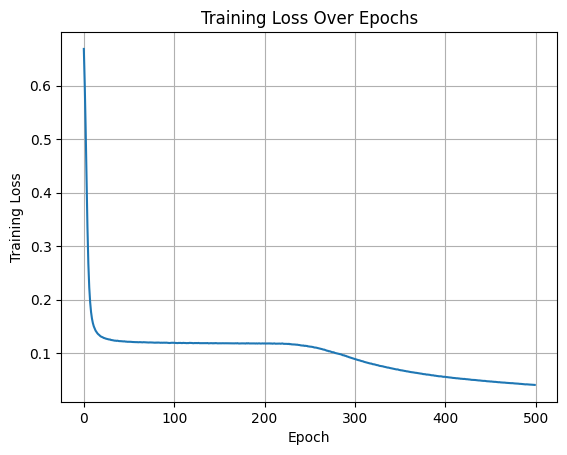

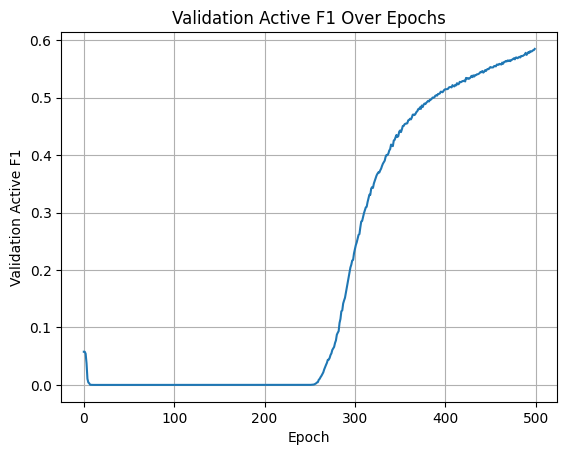

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_2_200425_161730.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 128
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6752
Best Val Epoch: 412


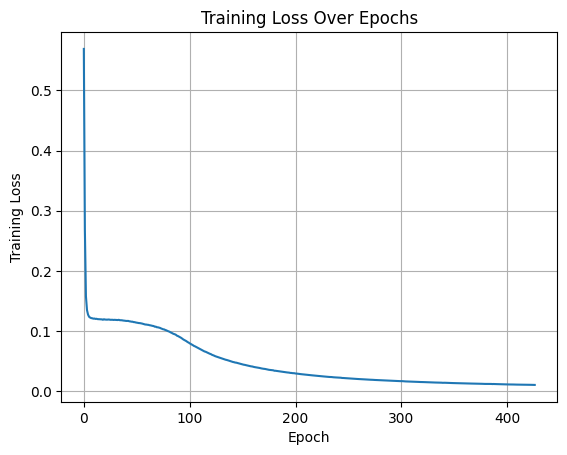

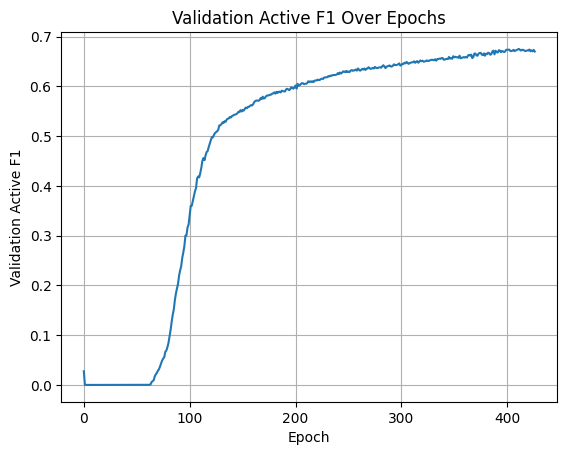

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_3_200425_165103.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 256
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.657
Best Val Epoch: 479


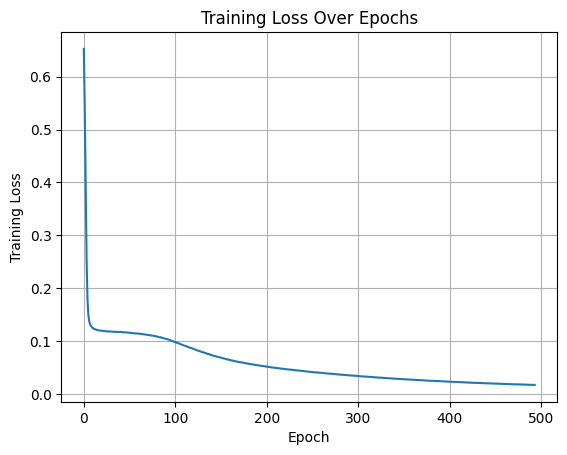

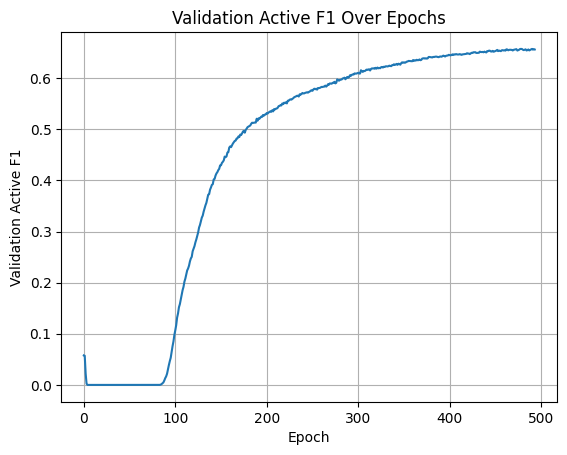

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_4_200425_172112.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 256
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6574
Best Val Epoch: 219


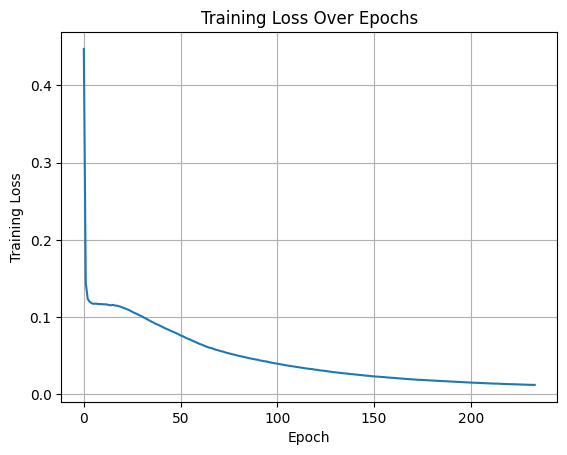

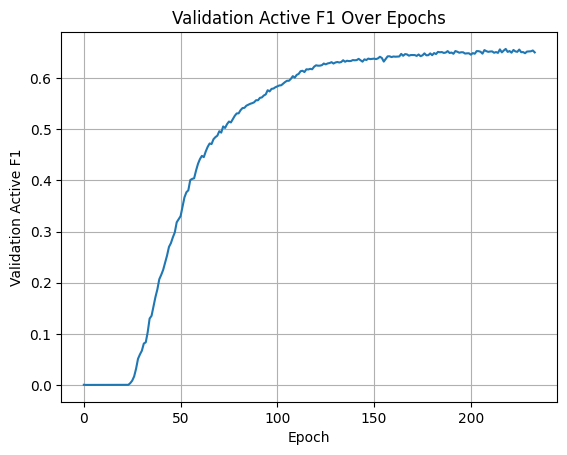

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_5_200425_175714.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6547
Best Val Epoch: 438


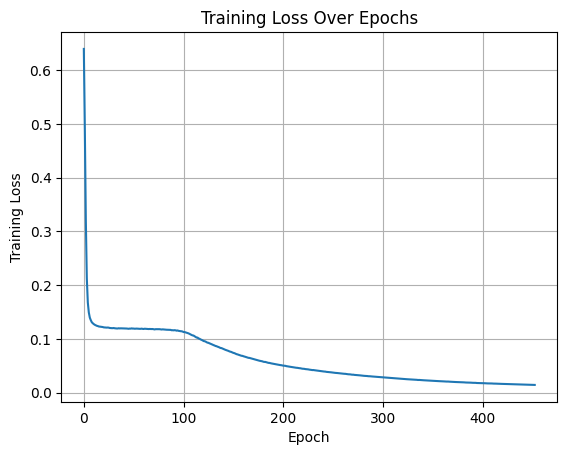

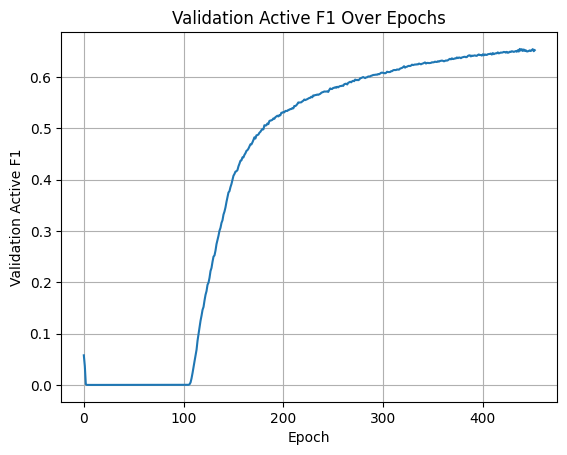

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_6_200425_181439.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6721
Best Val Epoch: 236


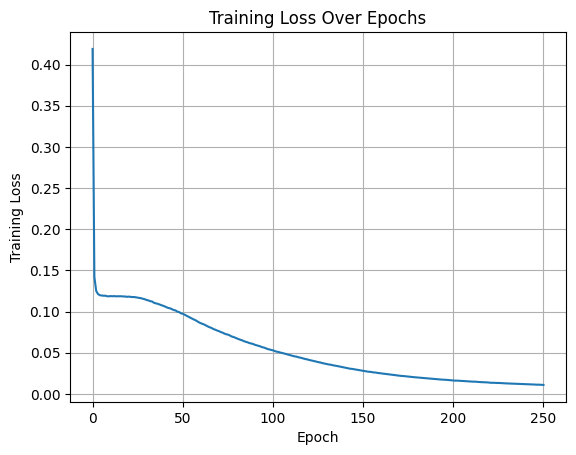

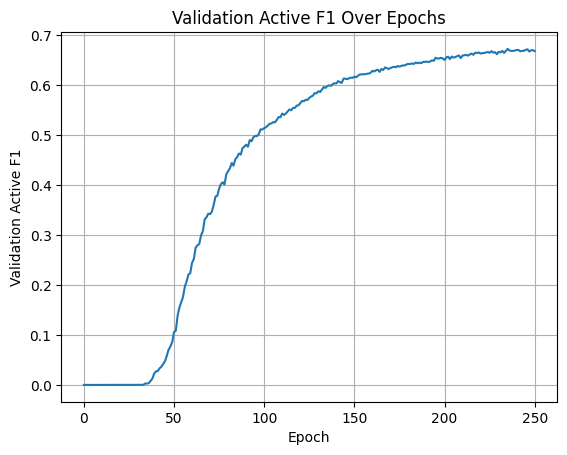

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/cqt/gru_7_200425_185046.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

## Transformers

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 128
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6942
Best Val Epoch: 468


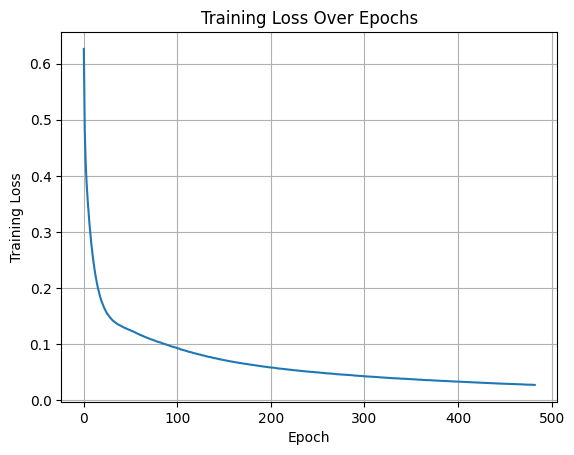

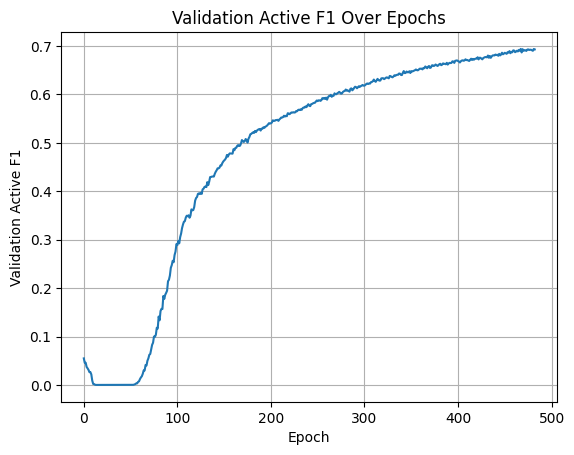

In [ ]:


with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_8_200425_191025.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()


Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 128
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7018
Best Val Epoch: 167


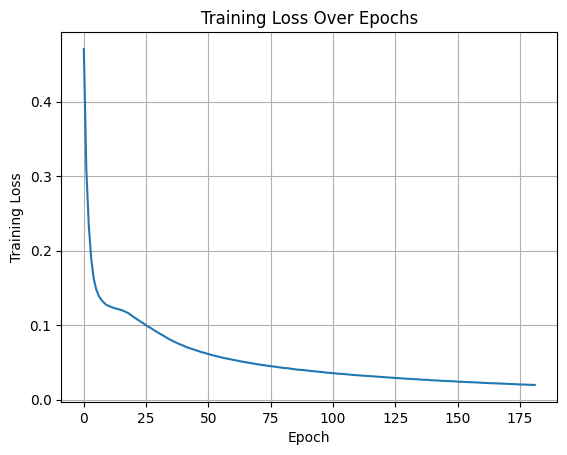

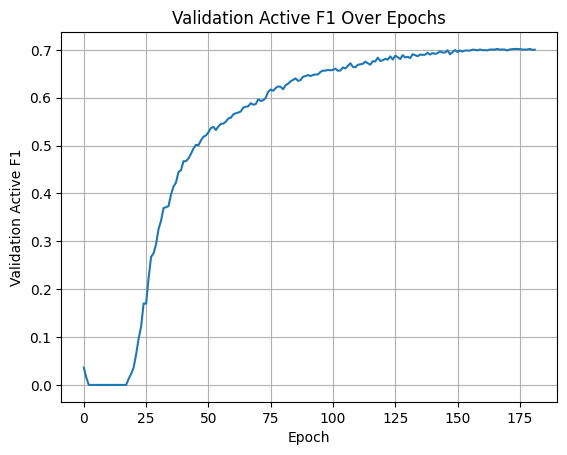

In [ ]:

with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_9_200425_194408.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 128
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.6779
Best Val Epoch: 499


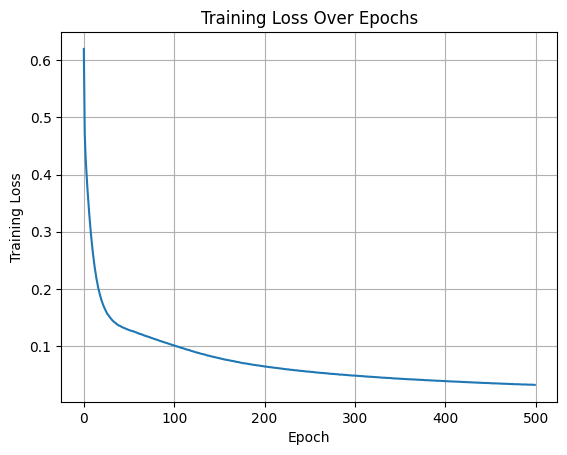

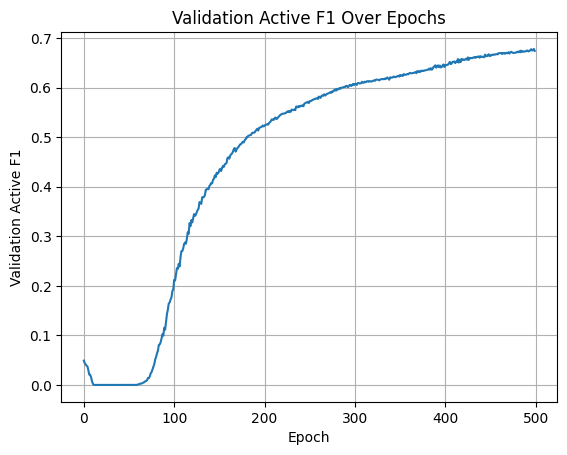

In [ ]:
import json
import matplotlib.pyplot as plt



with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_10_200425_195640.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 128
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7165
Best Val Epoch: 276


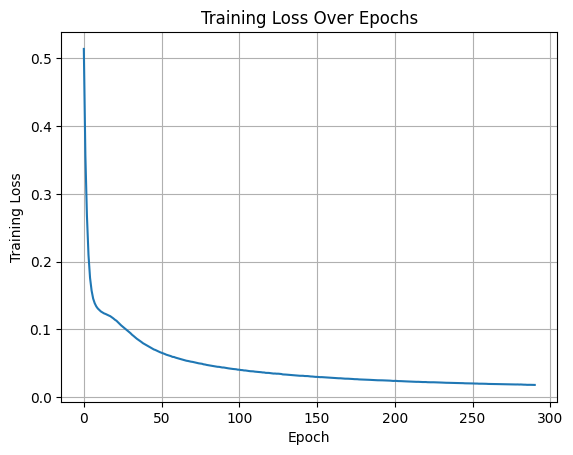

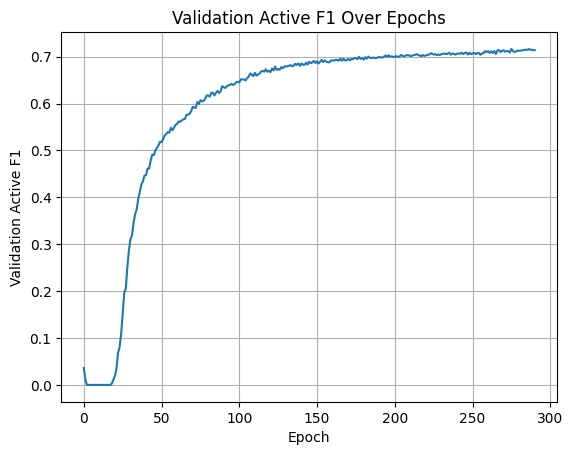

In [ ]:
import json
import matplotlib.pyplot as plt



with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_11_200425_203143.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7006
Best Val Epoch: 384


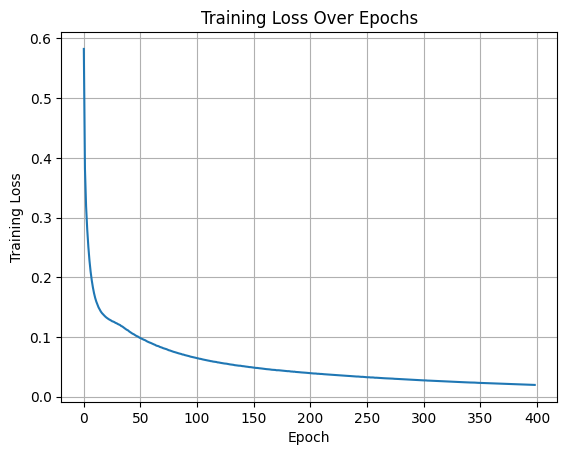

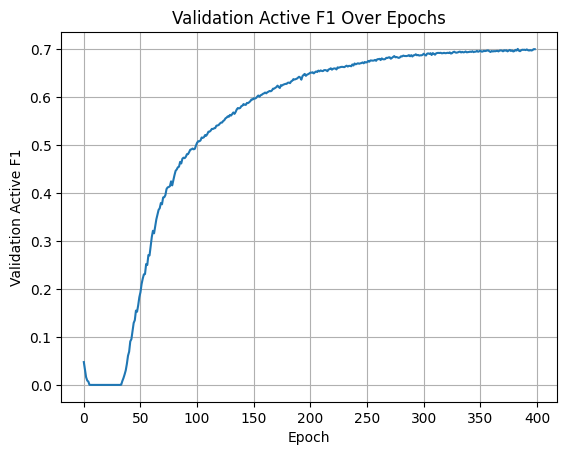

In [ ]:
import json
import matplotlib.pyplot as plt



with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_12_200425_205303.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7146
Best Val Epoch: 135


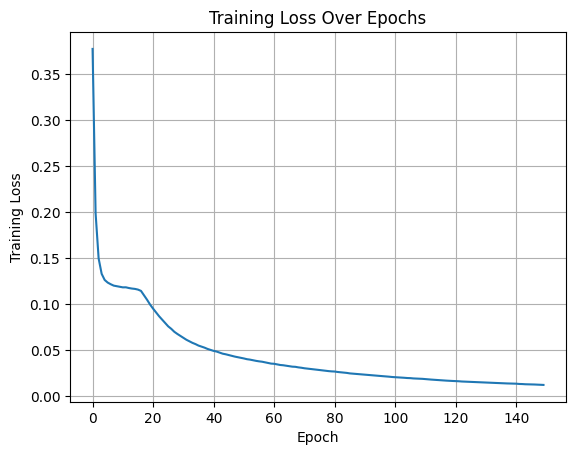

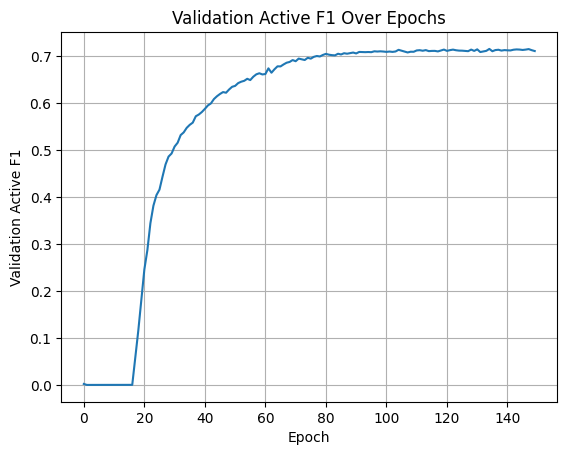

In [ ]:


import json
import matplotlib.pyplot as plt



with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_13_200425_212327.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7087
Best Val Epoch: 343


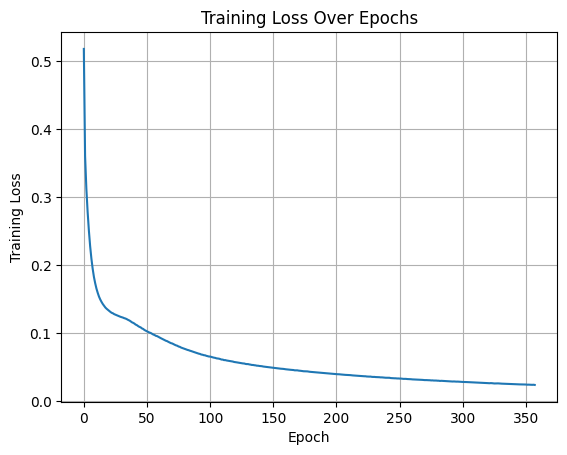

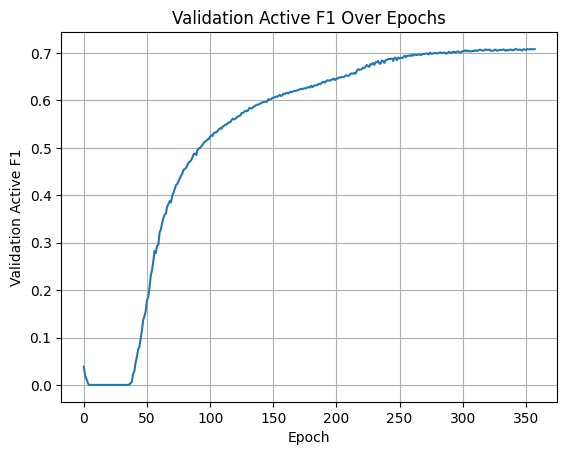

In [ ]:


with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_14_200425_213451.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()


Training Configuration
Model: transformer
Input Type: cqt
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.7265
Best Val Epoch: 209


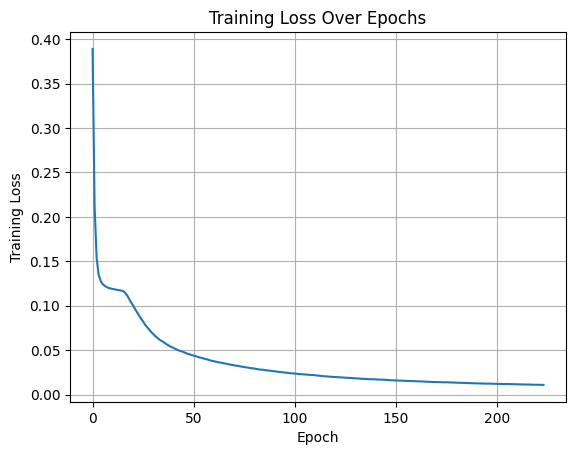

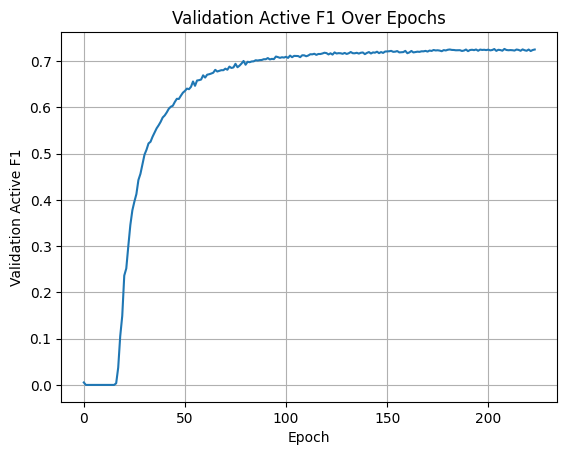

In [ ]:

with open("logs/Experiments/Parameter_Tuning/Transformer/cqt/transformer_15_200425_220248.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

# wav2vec

## GRU

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 128
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.1562
Best Val Epoch: 500


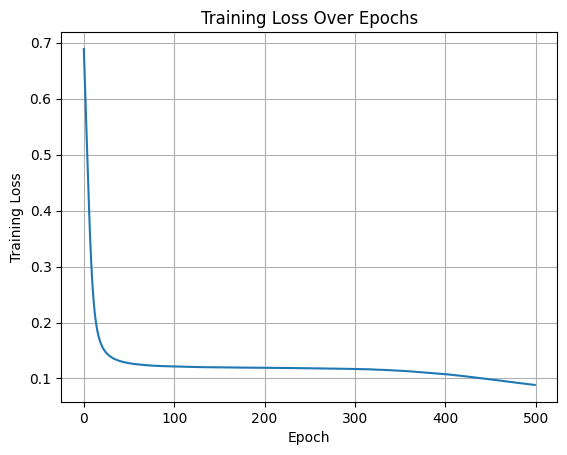

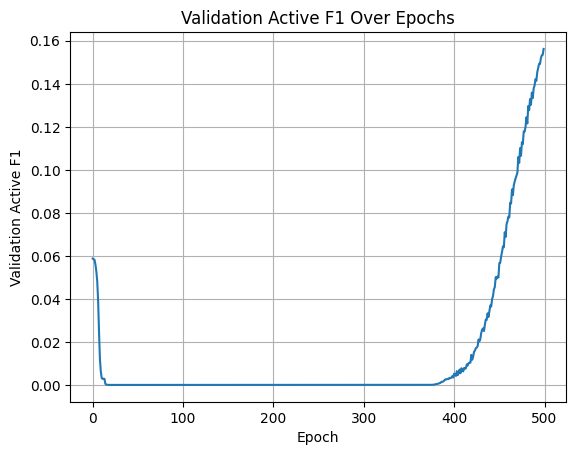

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_16_210425_095828.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 128
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3551
Best Val Epoch: 499


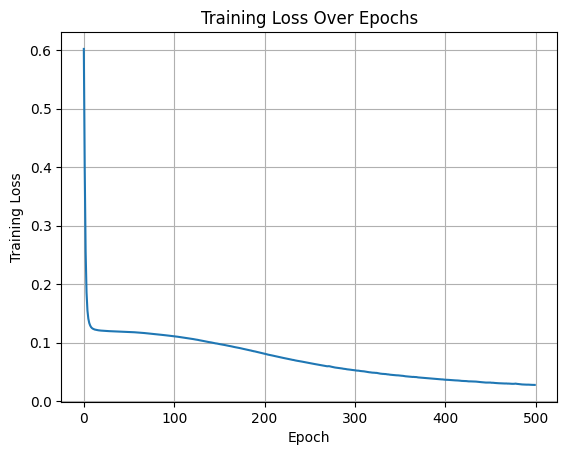

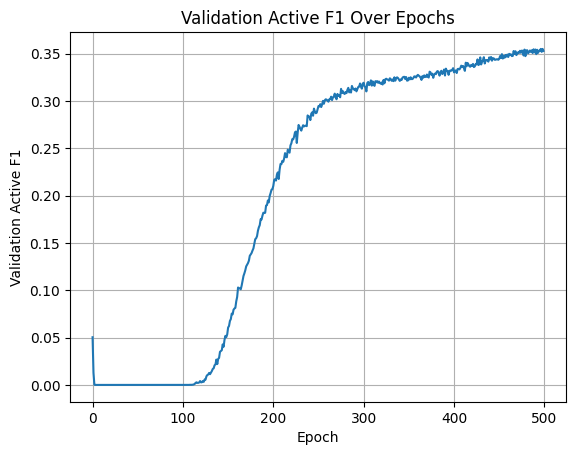

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_17_210425_102606.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 128
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.0591
Best Val Epoch: 3


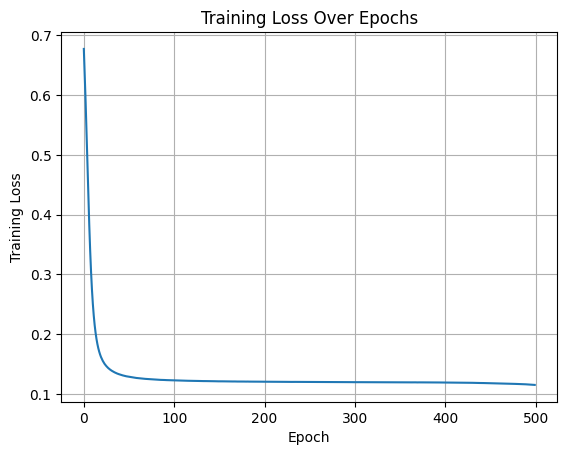

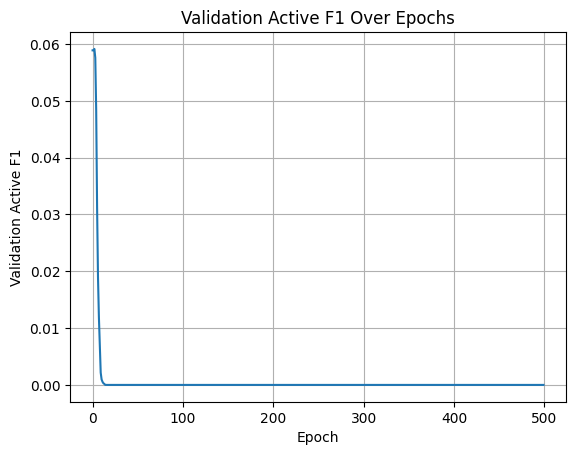

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_18_210425_105310.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 128
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3429
Best Val Epoch: 498


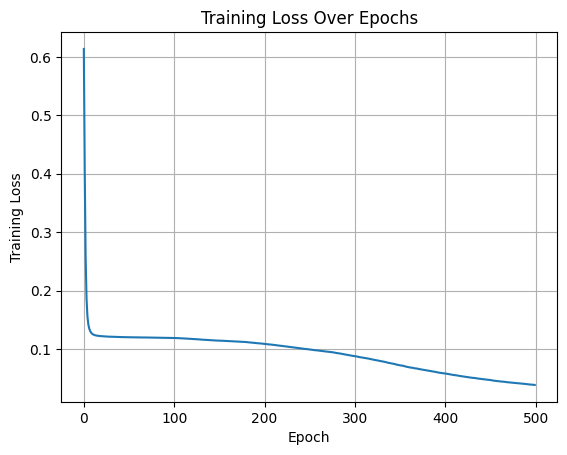

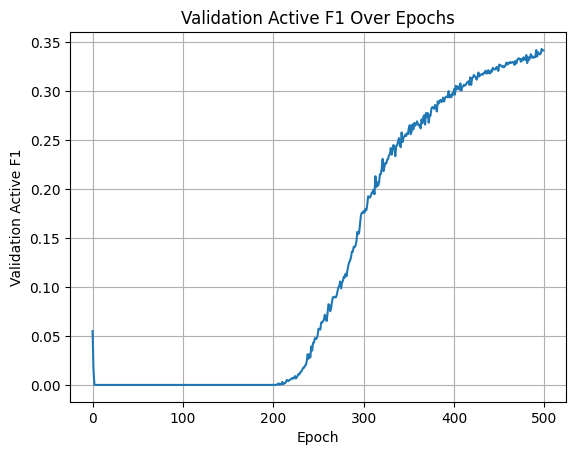

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_19_210425_111955.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 256
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3719
Best Val Epoch: 500


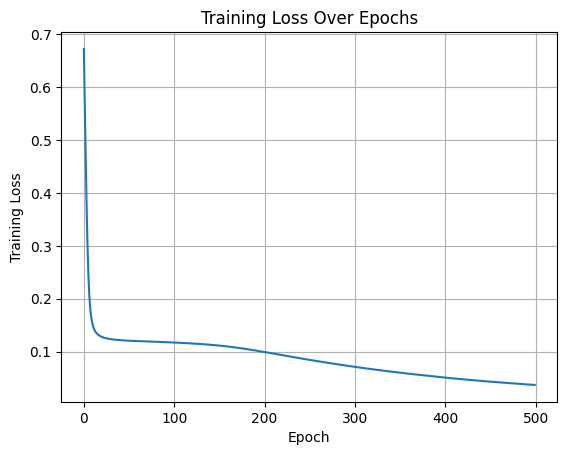

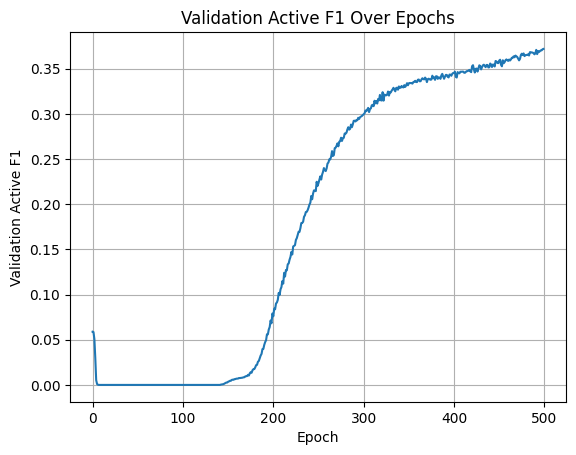

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_20_210425_114722.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 256
Num Layers: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3707
Best Val Epoch: 380


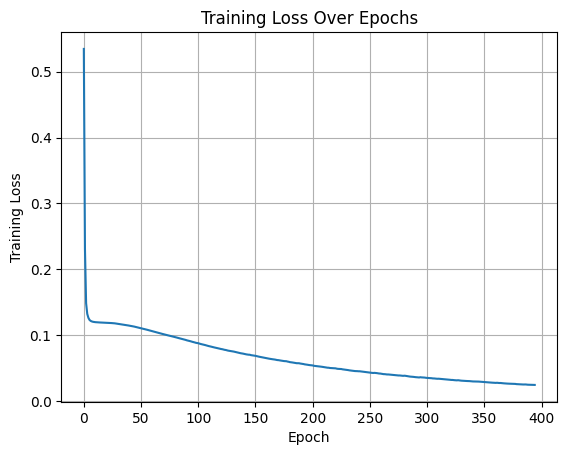

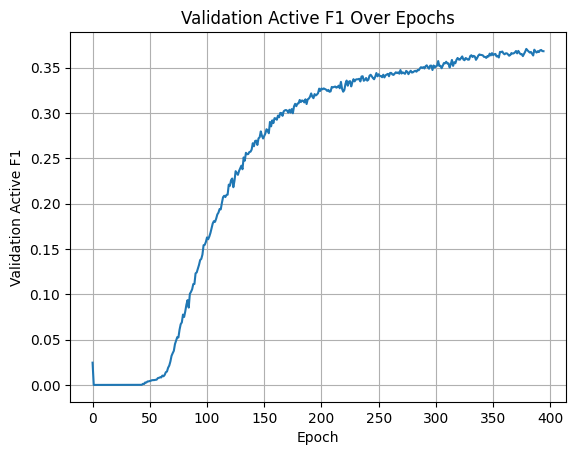

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_21_210425_121637.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 256
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.372
Best Val Epoch: 493


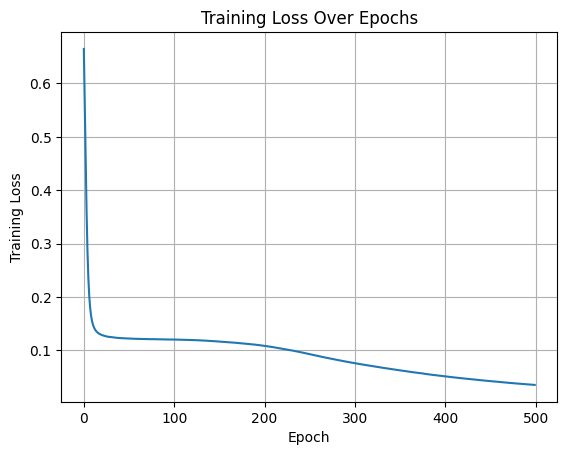

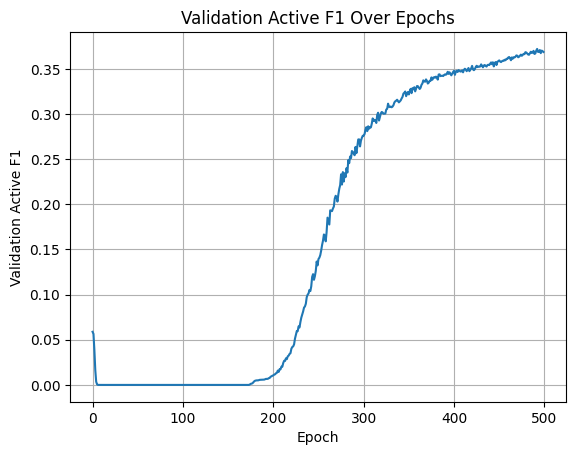

In [ ]:
with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_22_210425_124008.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: gru
Input Type: wav2vec
Model Dimension: 256
Num Layers: 3
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3742
Best Val Epoch: 396


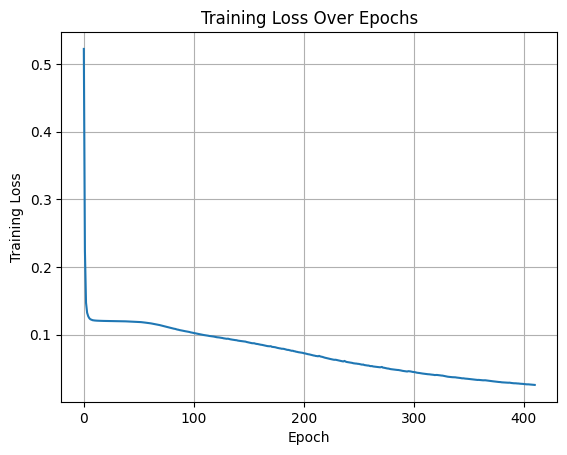

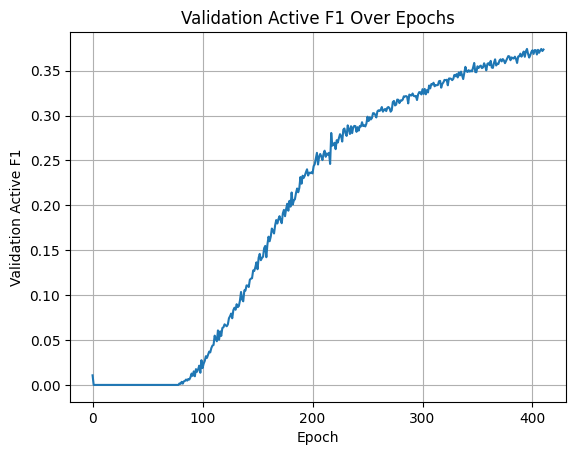

In [ ]:


with open("logs/Experiments/Parameter_Tuning/GRU/wav2vec/gru_23_210425_131042.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

## Transformers

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 128
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3267
Best Val Epoch: 496


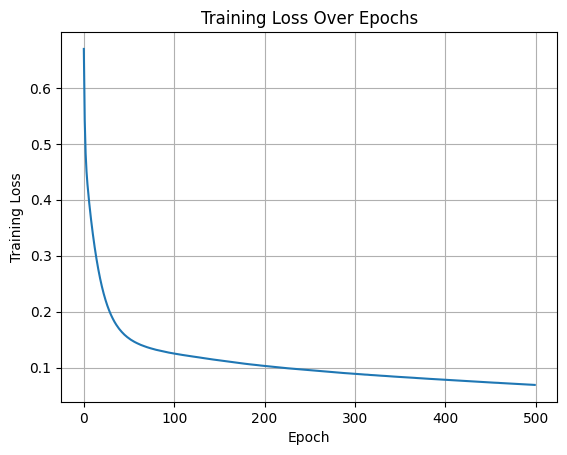

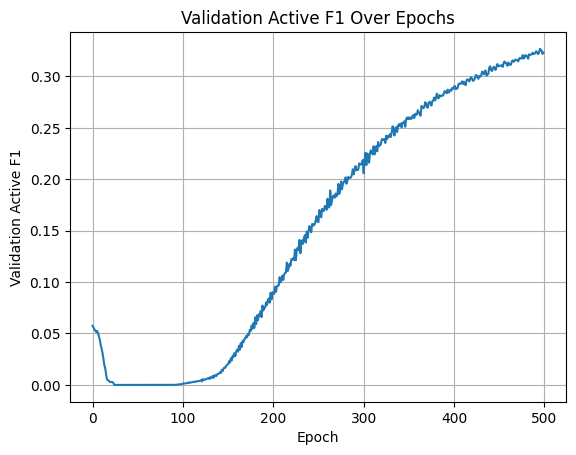

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_24_210425_133609.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 128
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3686
Best Val Epoch: 291


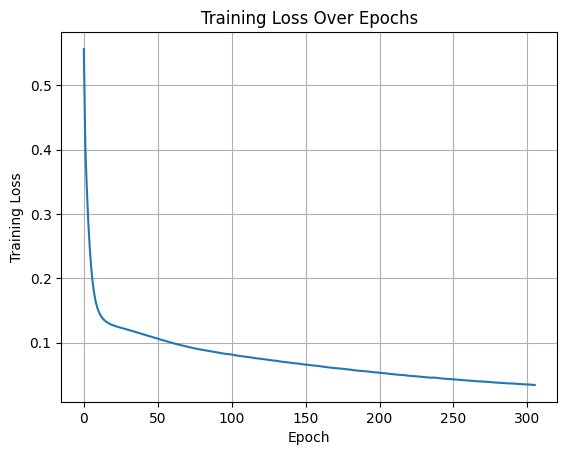

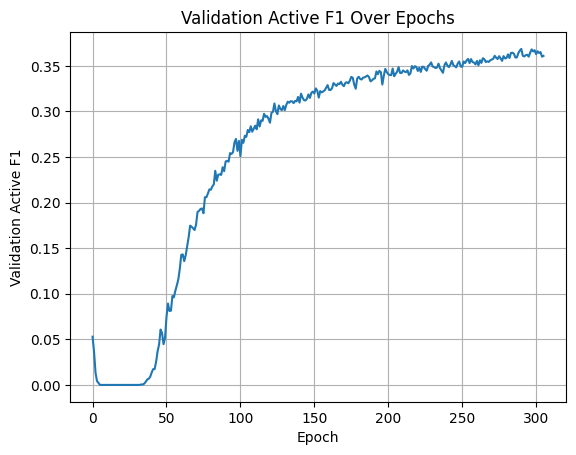

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_25_210425_140417.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 128
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3066
Best Val Epoch: 495


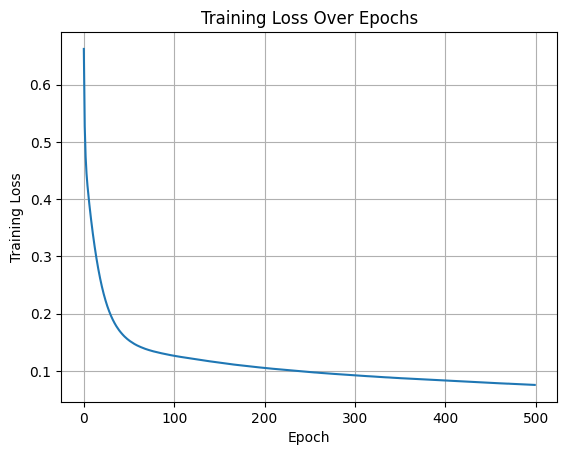

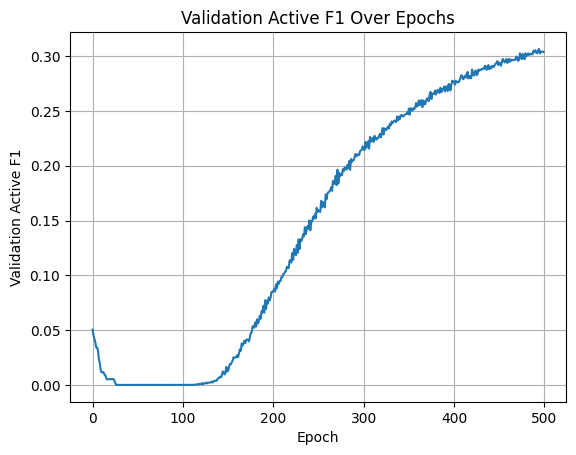

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_26_210425_142145.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 128
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3828
Best Val Epoch: 271


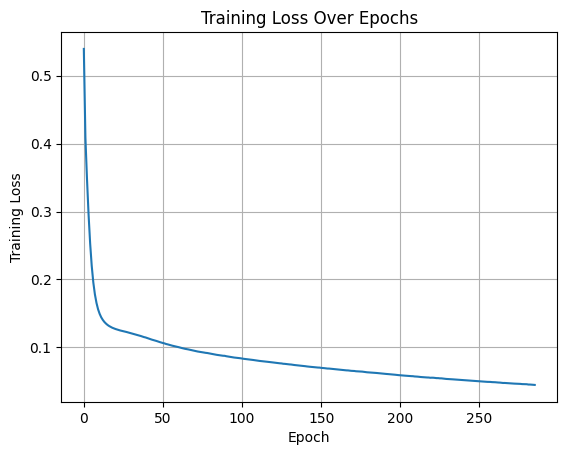

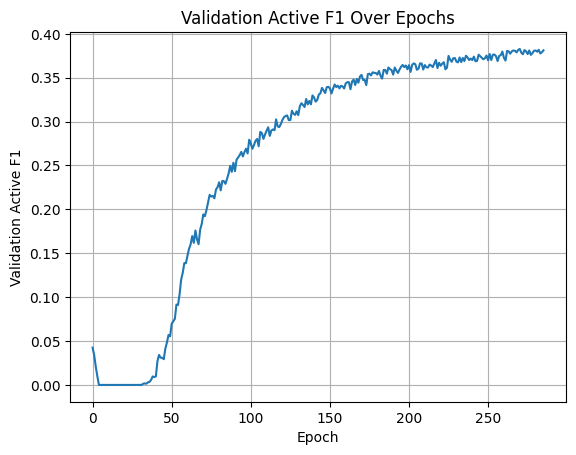

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_27_210425_145030.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 256
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3662
Best Val Epoch: 490


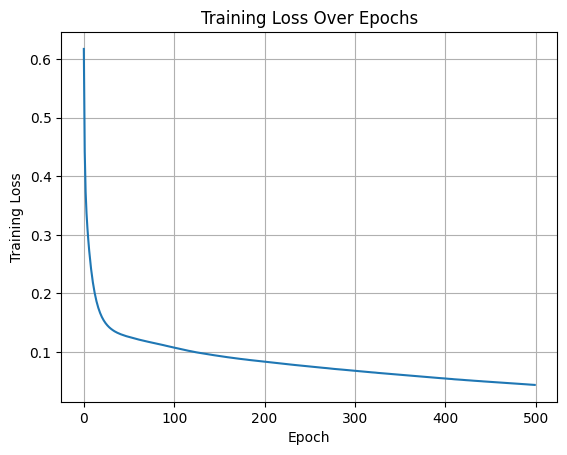

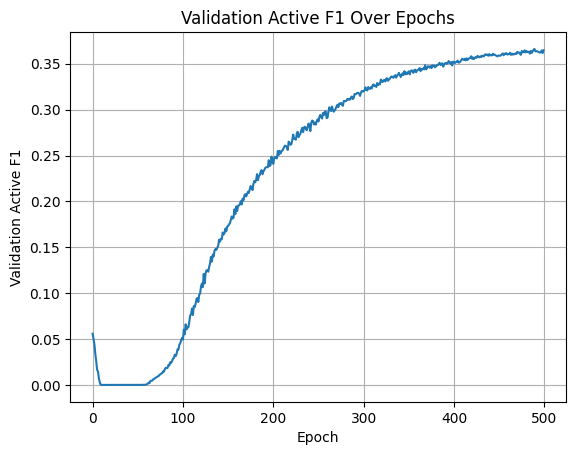

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_28_210425_150739.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 256
Num Layers: 2
Num Heads: 2
Dropout: 0.1
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.3782
Best Val Epoch: 151


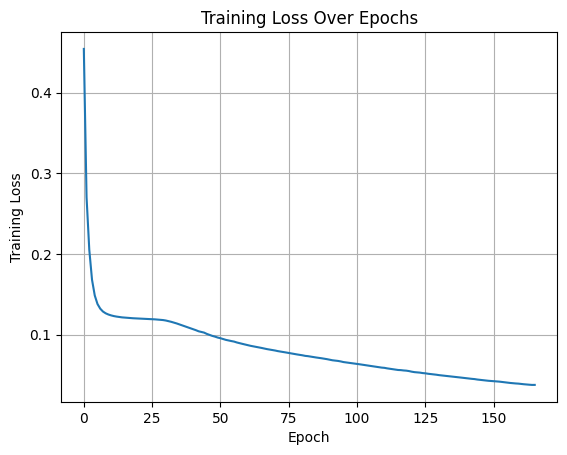

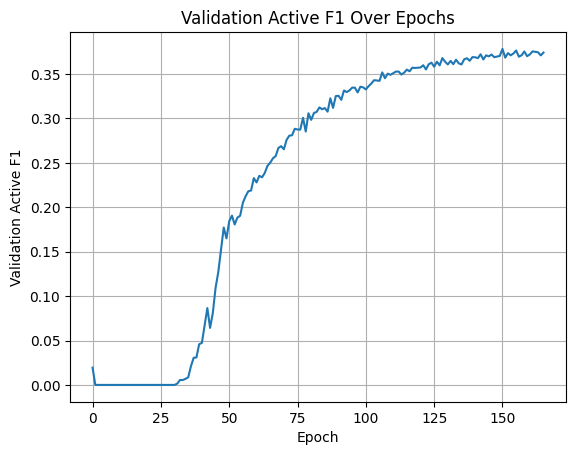

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_29_210425_153728.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0001
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.344
Best Val Epoch: 385


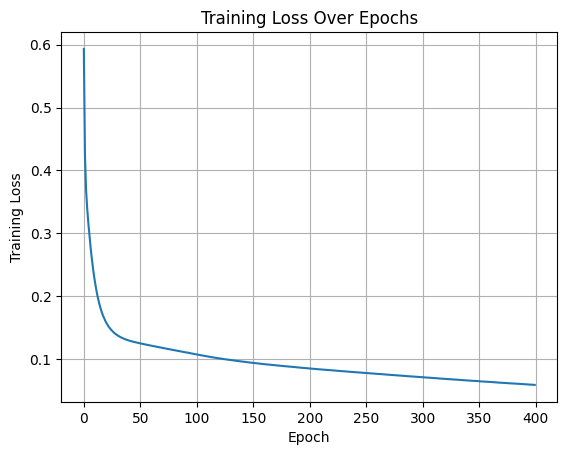

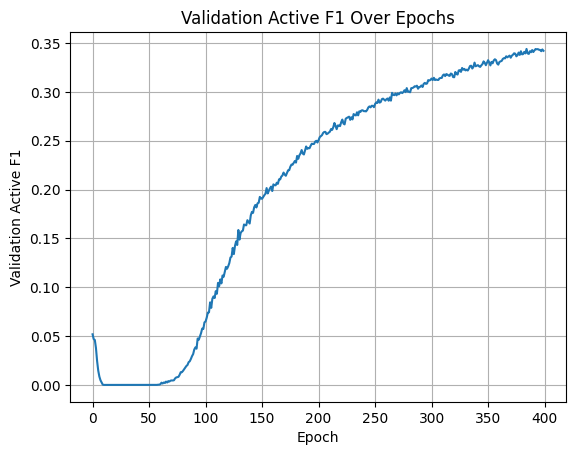

In [ ]:
with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_30_210425_154732.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

Training Configuration
Model: transformer
Input Type: wav2vec
Model Dimension: 256
Num Layers: 3
Num Heads: 4
Dropout: 0.3
Learning Rate: 0.0005
Batch Size: 128
Num Epochs: 500
Best Val F1: 0.4085
Best Val Epoch: 225


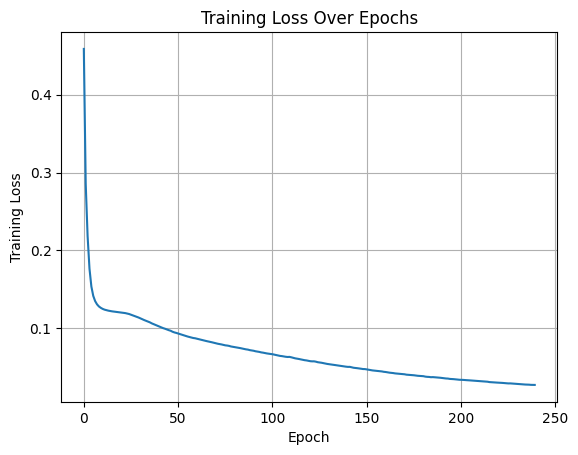

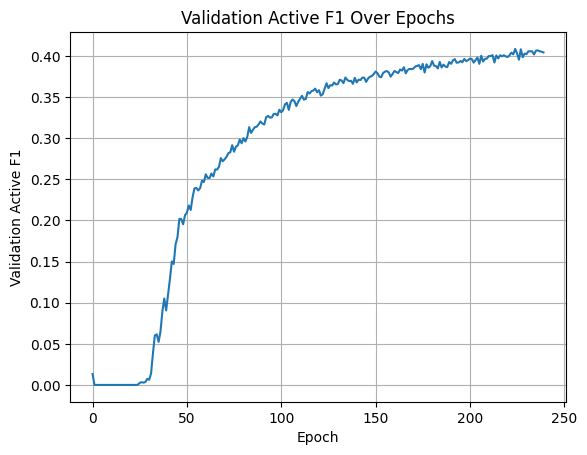

In [ ]:



with open("logs/Experiments/Parameter_Tuning/Transformer/wav2vec/transformer_31_210425_161203.json") as f:
    log = json.load(f)


# selected key parameters
key_params = {
    "Model": log["model_name"],
    "Input Type": log["input_type"],
    "Model Dimension": log["model_dim"],
    "Num Layers": log["num_layers"],
    "Num Heads": log["num_heads"],
    "Dropout": log["dropout"],
    "Learning Rate": log["lr"],
    "Batch Size": log["batch_size"],
    "Num Epochs": log["num_epochs"],
    "Best Val F1": round(log["best_val_f1"], 4),
    "Best Val Epoch": log["best_val_epoch"]
}

print("Training Configuration")
for k, v in key_params.items():
    print(f"{k}: {v}")

# Plot Training Loss
plt.plot(log["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# Plot Validation Active F1
plt.plot(log["val_f1s"])
plt.xlabel("Epoch")
plt.ylabel("Validation Active F1")
plt.title("Validation Active F1 Over Epochs")
plt.grid(True)
plt.show()

